# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

**1.** $\{x\in\mathbb{R}^2: x_2\ge x_1^2\}$ — **выпукло**.

Это надграфик функции $\varphi(x_1)=x_1^2$: множество $\{(x_1,x_2): x_2\ge\varphi(x_1)\}=\operatorname{epi}\varphi$. Так как $\varphi$ выпукла ($\varphi''=2>0$), надграфик выпукл по определению из раздела 3. Через раздел 5: $h(x)=x_2-x_1^2$ — вогнута (потому что $-h(x)=x_1^2-x_2$ выпукла как сумма выпуклой $x_1^2$ и аффинной $-x_2$), значит $\{h\ge0\}$ выпукло.

**2.** $\{x\in\mathbb{R}^n: \Vert Ax-b\Vert_2\le1\}$ — **выпукло при любых $A,b$**.

Это подуровневое множество $\{x: f(x)\le1\}$ функции $f(x)=\Vert Ax-b\Vert_2$, которая выпукла как композиция нормы (выпуклой) с аффинным отображением $x\mapsto Ax-b$ (как в 2-ой операции 5-го раздела). Подуровневое множество выпуклой функции выпукло (из раздела 5). Ранг и размеры $A$ не важны.

**3.** $\{x\in\mathbb{R}^2: \Vert x\Vert_2\ge1\}$ — **не выпукло.**

Контрпример: $x=(1,0)$, $y=(-1,0)$ — оба на границе ($\Vert x\Vert=\Vert y\Vert=1$), но середина $\tfrac12(x+y)=(0,0)$ имеет $\Vert(0,0)\Vert=0<1$ и не лежит в множестве. Это в точности «внешность шара» из 8-го раздела конспекта лекции — там же отмечено, что она не выпукла.

**(б)**

**Ответ:** 

**1.** $f(x)=x_1^2+ax_1x_2+x_2^2=\tfrac12x^\top Qx$ с $Q=\begin{pmatrix}2&a\\a&2\end{pmatrix}$ (гессиан не зависит от $x$). Собственные числа симметричной матрицы с равными диагональными элементами: $\lambda_{1,2}=2\pm a$ (на собственных векторах $(1,\pm1)$). Значит:
$$f\text{ выпукла}\Leftrightarrow  2-|a|\ge0 \Leftrightarrow  a\in[-2,2],\qquad f\text{ строго выпукла}\Leftrightarrow  a\in(-2,2).$$
При $a=\pm2$ имеем $f(x)=(x_1\pm x_2)^2$ - выпукла, но вырождена вдоль $x_1=\mp x_2$ (не строго выпукла), как $x^4$ в разделе 4. 


In [2]:
for a in [-3, -2, -1.9, 0, 1, 2, 2.5]:
    Q = np.array([[2.0, a], [a, 2.0]])
    print(a, np.linalg.eigvalsh(Q))

-3 [-1.  5.]
-2 [0. 4.]
-1.9 [0.1 3.9]
0 [2. 2.]
1 [1. 3.]
2 [0. 4.]
2.5 [-0.5  4.5]


**2.** $g(x)=x_1^2x_2^2$ — **не выпукла**. 

Гессиан
$$\nabla^2g=\begin{pmatrix}2x_2^2 & 4x_1x_2\\4x_1x_2 & 2x_1^2\end{pmatrix},\qquad \det\nabla^2g=4x_1^2x_2^2-16x_1^2x_2^2=-12x_1^2x_2^2\le0.$$
При $x_1x_2\ne0$ определитель строго отрицателен $\Rightarrow$ собственные числа разных знаков $\Rightarrow$ гессиан не является положительно полуопределённым ($\nabla^2g\not\succeq0$) — критерий второго порядка нарушен. Пример: в точке $(1,1)$ гессиан $\begin{pmatrix}2&4\\4&2\end{pmatrix}$ имеет собственные числа $\{-2,6\}$ — есть отрицательное собственное число, значит $\nabla^2 g(1,1)\not\succeq0$.


**(в)**

**Ответ:** 

**1.** $f(x)=\Vert Ax-b\Vert_2+\lambda\Vert x\Vert_\infty$, $\lambda\ge0$ — **выпукла**. 

Первое слагаемое — норма от аффинного отображения, второе — норма с неотрицательным коэффициентом $\lambda$; сумма выпуклых с неотрицательными весами выпукла. Негладкая — обе нормы недифференцируемы в нуле своего аргумента.

**2.** $f(x)=\max_i(a_i^\top x-b_i)^2$ — **выпукла**. 

Каждая $(a_i^\top x-b_i)^2$ — функция вида $u^2$, скомпонованная с аффинным $u=a_i^\top x-b_i$ (композиция с аффинным отображением не требует монотонности внешней функции) — выпукла. Максимум конечного числа выпуклых функций выпукл. Негладкая (в точках, где максимум переключается между разными $i$, возникает излом).

**3.** $f(x)=e^{-\Vert x\Vert_2^2}$ — **не выпукла**. 

Правило композиции здесь не применимо: внешняя $g(u)=e^{-u}$ хоть и выпукла, но убывает ($g'(u)=-e^{-u}<0$), а не является неубывающей. Прямой контрпример по определению: $x=-1,\,y=1$ ($n=1$), $f(x)=f(y)=e^{-1}\approx0.368$, но $f(0)=1$ на середине отрезка — хорда лежит ниже графика ($1>0.368$), нарушение неравенства $f(\text{mid})\le\text{avg}$. Численно: $f(\text{mid})=1.0000 > avg=0.3679$. Эквивалентно: $f$ ограничена ($f\le1$) и достигает максимума во внутренней точке $x=0$ — выпуклая функция не может иметь внутренний максимум, не будучи константой. Гладкая — $f\in C^\infty(\mathbb{R}^n)$.

**Какая гладкая?**

1. Негладкая

2. Негладкая

3. Гладкая

**(г)**

**Ответ:** 

| Задача | Выпукла? | Почему (цель - равенства - неравенства) |
|-------------|-------------|-------------|
| (a)    | да    | $f=\tfrac12\Vert x-p\Vert^2$ — квадратичная с $Q=I\succeq0$; равенства аффинны; неравенств нет.    |
| (б)    | да    | $f=c^\top x$ аффинна; равенств нет; $h=(Ax-b,\,x)$ - аффинны, значит вогнуты (аффинные функции одновременно выпуклы и вогнуты). LP всегда выпукла.    |
| (в)    | нет    | Хотя ограничения ($h_1=1-x_1^2-x_2^2$ вогнута, $h_2=x_1,h_3=x_2$ аффинны) задают выпуклое множество (четверть круга), цель $f(x)=-4x_1x_2$ не выпукла: гессиан $\begin{pmatrix}0&-4\\-4&0\end{pmatrix}$ имеет собственные числа $\pm4$ — индефинитен.    |
| (г)    | нет    | $f$ не аффинна и не квадратична с фиксированным $Q$ — нужно доказывать отдельно. Прямое доказательство: модель обладает точной симметрией $x_1\sin(x_2t+x_3)\equiv(-x_1)\sin(x_2t+x_3+\pi)$, поэтому если $x^\ast=(x_1^\ast,x_2^\ast,x_3^\ast)$ — глобальный минимум с $x_1^\ast\ne0$, то и $(-x_1^\ast,x_2^\ast,x_3^\ast+\pi)$ — тоже глобальный минимум с тем же значением $f$. Множество решений состоит из (как минимум) двух изолированных точек — не выпуклое множество, а у выпуклой задачи множество решений обязано быть выпуклым. Противоречие $\Rightarrow$ задача не выпукла.    |
| (д)    | да    | $f(x,s)=s$ аффинна; равенств нет; все $h_i=\pm(s-(a_i^\top x-b_i))$ аффинны ($\Rightarrow$ вогнуты). Это LP, LP всегда выпукла.    |


## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:** 

Пусть $x^\ast$ - решение задачи $\min_{x\in\Omega}\tfrac12\Vert x-p\Vert^2$, $\Omega=\{x:a^\top x\le b\}$, $\nabla f(x^\ast)=x^\ast-p$.

**(i)** $x^\ast$ лежит на границе, $a^\top x^\ast=b$. Если бы $a^\top x^\ast<b$, то $x^\ast$ лежал бы внутри $\Omega$, и в направлении $y=x^\ast-t\nabla f(x^\ast)$ при малом $t>0$ точка допустима (не выходит из полупространства при достаточно малом $t$), а условие оптимальности $\nabla f(x^\ast)^\top(y-x^\ast)\ge0$ даёт $-t\Vert\nabla f(x^\ast)\Vert^2\ge0$, то есть $\nabla f(x^\ast)=0\Rightarrow x^\ast=p$. Но $p\notin\Omega$ по условию — противоречие. Значит $a^\top x^\ast=b$.

**(ii)** $x^\ast-p\parallel a$. Для любого $v\perp a$ (т.е. $a^\top v=0$) точки $y=x^\ast\pm v$ допустимы: $a^\top y = a^\top x^\ast\pm a^\top v=b$. Подставляя оба знака в условие оптимальности:
$$(x^\ast-p)^\top v\ge0\quad\text{и}\quad -(x^\ast-p)^\top v\ge0 \ \Rightarrow\ (x^\ast-p)^\top v=0\quad\forall v\perp a.$$
Значит $x^\ast-p$ ортогонален всему ортогональному дополнению вектора $a$, то есть $x^\ast-p=\lambda a$ для некоторого скаляра $\lambda$.

**(iii)** Коэффициент $\lambda$. Из $a^\top x^\ast=b$: $a^\top(p+\lambda a)=a^\top p+\lambda\Vert a\Vert^2=b\ \Rightarrow\ \lambda=\dfrac{b-a^\top p}{\Vert a\Vert^2}=-\dfrac{a^\top p-b}{\Vert a\Vert^2}$.
Итого:
$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a.$$

**(iv)** Проверка для всех $y\in\Omega$. Так как $a^\top p>b$, коэффициент $\lambda<0$. Для произвольного допустимого $y$ (то есть $a^\top y\le b$):
$$\nabla f(x^\ast)^\top(y-x^\ast)=(x^\ast-p)^\top(y-x^\ast)=\lambda a^\top(y-x^\ast)=\lambda(a^\top y-b)\ge0,$$
так как $\lambda<0$ и $a^\top y-b\le0$ - произведение неотрицательного на неотрицательное (два неположительных множителя). Условие выполнено для всех $y\in\Omega$, значит по теореме найденная точка - глобальное решение.



**Численная проверка (пункты 2 и 3)**

In [4]:
import numpy as np
from scipy.optimize import minimize

rng = np.random.default_rng(2026)

a = np.array([1.0, 2.0, -1.0])
b = 1.0
p = np.array([3.0, 1.0, 0.5])
assert a @ p > b

x_formula = p - (a @ p - b) / (a @ a) * a
print("x* по формуле =", x_formula)

f = lambda x: 0.5 * np.sum((x - p) ** 2)
grad_f = lambda x: x - p
constraints = [{'type': 'ineq', 'fun': lambda x: b - a @ x}]

res = minimize(f, x0=np.zeros(3), jac=grad_f, constraints=constraints, method='SLSQP')
print("x* численно   =", res.x)
print("|x_num - x_formula| =", np.linalg.norm(res.x - x_formula))

def sample_feasible(n_points, n=3, scale=10.0):
    pts = []
    while len(pts) < n_points:
        batch = rng.uniform(-scale, scale, size=(n_points * 3, n))
        pts.extend(batch[batch @ a <= b])
    return np.array(pts[:n_points])

Y = sample_feasible(2000)

def check_optimality(x_point, label):
    g = x_point - p
    vals = (Y - x_point) @ g
    print(f"{label}: min_y grad_f(x)^T (y - x) = {vals.min():.4f}")

check_optimality(x_formula, "x* (наша проекция)")
check_optimality(np.zeros(3), "x = 0 (заведомо не оптимальна)")


x* по формуле = [ 2.41666667 -0.16666667  1.08333333]
x* численно   = [ 2.41666667 -0.16666667  1.08333333]
|x_num - x_formula| = 8.308148362110449e-16
x* (наша проекция): min_y grad_f(x)^T (y - x) = 0.0072
x = 0 (заведомо не оптимальна): min_y grad_f(x)^T (y - x) = -32.9438


**Ответ:** 

Знак $\min_y \nabla f(x)^\top(y-x)$ - это и есть прямая проверка условия оптимальности раздела 7 без решения задачи заново. Если минимум по всем допустимым $y$ неотрицателен (как для $x^\ast$, с точностью до шума конечной выборки случайных точек), значит ни в одном допустимом направлении функция не убывает в первом порядке - точка удовлетворяет необходимому и достаточному условию, то есть является глобальным решением. Если же минимум отрицателен (как для $x=0$: $-32.94<0$), это означает, что нашлось допустимое направление убывания $y-x$, вдоль которого $f$ в первом порядке уменьшается - значит, точка не оптимальна, и это конкретное $y$ (или направление к нему) подсказывает, куда двигаться, чтобы уменьшить $f$.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

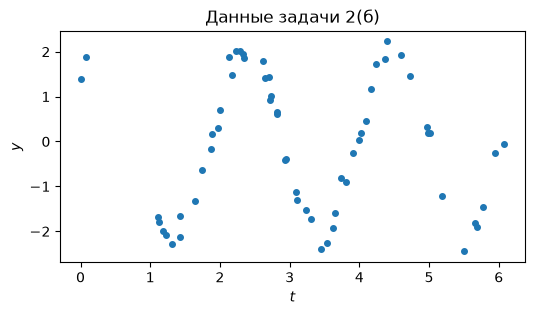

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:** 

**Модель B:** $\varphi_B(t;x)=x_1\sin\omega t+x_2\cos\omega t$ линейна по $x=(x_1,x_2)$ ($\omega$ фиксирована). Значит

$$f_B(x)=\tfrac12\Vert Cx-y\Vert^2,\qquad C=\big[\sin\omega t_i,\ \cos\omega t_i\big]_{i=1}^N\in\mathbb{R}^{N\times2},$$

- квадратичная функция с гессианом $Q=C^\top C$. Для любого $v$: $v^\top Qv=\Vert Cv\Vert^2\ge0$, значит $Q\succeq0$ всегда. Класс: QP (линейный МНК), без ограничений, выпукла (строго выпукла при $N\ge2$ различных $t_i$, когда столбцы $C$ линейно независимы).

**Модель A:** $\varphi_A(t;x)=x_1\sin(x_2t+x_3)$ нелинейна по $x_2,x_3$ - это нелинейный МНК, класс NLP, без ограничений, и она не выпукла. Доказательство - точные симметрии модели, не требующие вычисления гессиана:
1. При $x_3\to x_3+2\pi$: $\sin(x_2t+x_3+2\pi)\equiv\sin(x_2t+x_3)$ для всех $t$ - значит $f_A(x_1,x_2,x_3+2\pi)\equiv f_A(x_1,x_2,x_3)$ тождественно.
2. При $(x_1,x_3)\to(-x_1,x_3+\pi)$: $(-x_1)\sin(x_2t+x_3+\pi)=(-x_1)\cdot(-\sin(x_2t+x_3))=x_1\sin(x_2t+x_3)$ - тоже тождественное совпадение.

Обе замены не меняют значение $f_A$ ни в одной точке $t$, то есть если $x^\ast$ - глобальный минимум, то и бесконечная серия точек $x^\ast+(0,0,2\pi k)$ и $(-x_1^\ast,x_2^\ast,x_3^\ast+\pi+2\pi k)$, $k\in\mathbb{Z}$ - тоже глобальные минимумы с тем же значением $f_A$. Это дискретное, не связное множество изолированных точек - оно не выпукло. Но множество решений выпуклой задачи обязано быть выпуклым (следствие из главной теоремы) - противоречие. Значит $f_A$ НЕ ВЫПУКЛА.


**Мультистарт (пункт 2)**

f по стартам, модель A: [ 1.1393 63.8249  1.1393  1.1393  1.1393 61.4973 61.4973 64.2518  1.1393
 63.8249  1.1393  1.1393 61.4973  1.1393 64.2518  1.1393 61.6882  1.1393
 61.4973  1.1393]
лучшее f_A* = 1.139273, доля стартов к нему: 0.55
f по стартам, модель B: [1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408
 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408]
лучшее f_B* = 1.140764, доля стартов к нему: 1.00


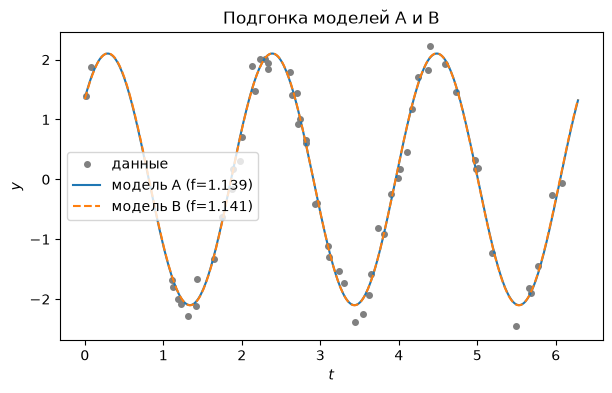

In [6]:
data_rng = np.random.default_rng(2026)
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))

# модель A
def f_A(x):
    x1, x2, x3 = x
    r = x1 * np.sin(x2 * t + x3) - y
    return 0.5 * np.sum(r**2)

def grad_A(x):
    x1, x2, x3 = x
    s, c = np.sin(x2 * t + x3), np.cos(x2 * t + x3)
    r = x1 * s - y
    return np.array([np.sum(r * s), np.sum(r * x1 * t * c), np.sum(r * x1 * c)])

# модель B
S, C = np.sin(omega * t), np.cos(omega * t)

def f_B(x):
    x1, x2 = x
    r = x1 * S + x2 * C - y
    return 0.5 * np.sum(r**2)

def grad_B(x):
    x1, x2 = x
    r = x1 * S + x2 * C - y
    return np.array([np.sum(r * S), np.sum(r * C)])

# мультистарт
res_A, res_B = [], []
for x0 in starts:
    rA = minimize(f_A, x0, jac=grad_A, method="BFGS")
    res_A.append((rA.x, rA.fun))
    rB = minimize(f_B, x0[:2], jac=grad_B, method="BFGS")
    res_B.append((rB.x, rB.fun))

fA_vals = np.array([r[1] for r in res_A])
fB_vals = np.array([r[1] for r in res_B])
fA_best, fB_best = fA_vals.min(), fB_vals.min()

tol = 1e-4
frac_A = np.mean(np.isclose(fA_vals, fA_best, atol=tol))
frac_B = np.mean(np.isclose(fB_vals, fB_best, atol=tol))

print("f по стартам, модель A:", np.round(fA_vals, 4))
print(f"лучшее f_A* = {fA_best:.6f}, доля стартов к нему: {frac_A:.2f}")
print("f по стартам, модель B:", np.round(fB_vals, 4))
print(f"лучшее f_B* = {fB_best:.6f}, доля стартов к нему: {frac_B:.2f}")

# графики
xA_best = res_A[np.argmin(fA_vals)][0]
xB_best = res_B[np.argmin(fB_vals)][0]
tt = np.linspace(0, 2*np.pi, 400)
yA = xA_best[0]*np.sin(xA_best[1]*tt + xA_best[2])
yB = xB_best[0]*np.sin(omega*tt) + xB_best[1]*np.cos(omega*tt)

plt.figure(figsize=(7,4))
plt.plot(t, y, "o", ms=4, label="данные", color="gray")
plt.plot(tt, yA, "-", label=f"модель A (f={fA_best:.3f})")
plt.plot(tt, yB, "--", label=f"модель B (f={fB_best:.3f})")
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.legend()
plt.title("Подгонка моделей A и B")
plt.show()

**Объяснение (пункт 3)**

**Ответ:** 

У **B** задача выпукла — по теореме любой найденный локальный минимум глобален, поэтому все 20 стартов сходятся в одну и ту же точку $x_B^\ast$ (100%). У **A** теорема не применима: задача не выпукла, поэтому разные старты попадают в разные стационарные точки - только 55% доходят до наилучшего значения, остальные застревают в плохих локальных минимумах (обычно при $x_2\approx0$).

Из решения **B** параметры **A** получаются тождеством $x_1\sin\omega t+x_2\cos\omega t=R\sin(\omega t+\psi)$ с $R=\sqrt{x_1^2+x_2^2}$, $\psi=\operatorname{atan2}(x_2,x_1)$: $x_B^\ast=(1.6234,\,1.3378)\Rightarrow R\approx2.10,\ \psi\approx0.69$ - совпадает с истинными $2.0$ и $0.7$.

$f_A^\ast$ чуть меньше $f_B^\ast$, потому что у **A** на одну степень свободы больше (ещё и частота $x_2$ подстраивается под шум конкретной выборки) - это переобучение, а не преимущество: та же свобода делает задачу невыпуклой, без гарантии глобальности решения с одного старта.


## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** 

Пусть $x^\ast=P(p)$, $z^\ast=P(q)$. Условие оптимальности раздела 7 для задачи $\min_{x\in\Omega}\tfrac12\Vert x-p\Vert^2$ в точке $x^\ast$, взятое с пробной точкой $y=z^\ast\in\Omega$:

$$(x^\ast-p)^\top(z^\ast-x^\ast)\ge0.$$

Аналогично для задачи $\min_{x\in\Omega}\tfrac12\Vert x-q\Vert^2$ в точке $z^\ast$, с пробной точкой $y=x^\ast\in\Omega$:

$$(z^\ast-q)^\top(x^\ast-z^\ast)\ge0$$

Складываем первые два выражения:

$$(x^\ast-p)^\top(z^\ast-x^\ast)+(z^\ast-q)^\top(x^\ast-z^\ast)\ge0.$$

Раскрываем скобки (обозначим $d=x^\ast-z^\ast$ для краткости): после приведения подобных членов сумма равна

$$-\Vert x^\ast-z^\ast\Vert^2+(p-q)^\top(x^\ast-z^\ast)\ge0,$$

то есть

$$(p-q)^\top(x^\ast-z^\ast)\ge\Vert x^\ast-z^\ast\Vert^2.$$

По неравенству Коши–Буняковского левая часть выражения выше не превосходит $\Vert p-q\Vert\cdot\Vert x^\ast-z^\ast\Vert$:

$$\Vert x^\ast-z^\ast\Vert^2\le(p-q)^\top(x^\ast-z^\ast)\le\Vert p-q\Vert\,\Vert x^\ast-z^\ast\Vert.$$

Если $x^\ast=z^\ast$ - неравенство $\Vert P(p)-P(q)\Vert\le\Vert p-q\Vert$ тривиально ($0\le\Vert p-q\Vert$). Иначе делим обе части на $\Vert x^\ast-z^\ast\Vert>0$:

$$\Vert x^\ast-z^\ast\Vert\le\Vert p-q\Vert,\qquad\text{т.е.}\qquad \Vert P(p)-P(q)\Vert\le\Vert p-q\Vert.$$



In [7]:
rng = np.random.default_rng(2026)

def proj_ball(x, r=1.0):
    norm = np.linalg.norm(x)
    return x / max(1.0, norm / r)

def proj_cube(x, lo=-1.0, hi=1.0):
    return np.clip(x, lo, hi)

n, n_pairs, scale = 5, 1000, 5.0
P = rng.uniform(-scale, scale, size=(n_pairs, n))
Q = rng.uniform(-scale, scale, size=(n_pairs, n))
rhs = np.linalg.norm(P - Q, axis=1)

lhs_ball = np.array([np.linalg.norm(proj_ball(p) - proj_ball(q)) for p, q in zip(P, Q)])
lhs_cube = np.array([np.linalg.norm(proj_cube(p) - proj_cube(q)) for p, q in zip(P, Q)])

print("Шар: max(||P(p)-P(q)|| - ||p-q||) =", np.max(lhs_ball - rhs))
print("Шар: доля пар, где неравенство выполнено:", np.mean(lhs_ball <= rhs + 1e-12))
print("Куб: max(||P(p)-P(q)|| - ||p-q||) =", np.max(lhs_cube - rhs))
print("Куб: доля пар, где неравенство выполнено:", np.mean(lhs_cube <= rhs + 1e-12))

Шар: max(||P(p)-P(q)|| - ||p-q||) = -0.7211467708522106
Шар: доля пар, где неравенство выполнено: 1.0
Куб: max(||P(p)-P(q)|| - ||p-q||) = -0.00777961731042609
Куб: доля пар, где неравенство выполнено: 1.0


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).